<h1 style='font:size30px'>SUPPORT VECTOR MACHINES</h1>

<p style="font-size:20px">At this script we are goning to impelment and compare:<p>
<ol style='font-size:20px'>
    <li>Hard-Margin SVM            (manual (cvxpy) + built-in (scikit-learn))</li>
    <li>Soft-Margin SVM            (manual (cvxpy) + built-in (scikit-learn))</li>
    <li>Kernel SVM                 (manual (cvxpy, dual form) + built-in (scikit-learn))</li>
    <li>Logistic Regression        (baseline)</li>
</ol>
<p style="font-size:20px">All models are evaluated with Precision, Recall, F1-Score, and Accuracy.
A Bonus section tunes the regularization parameter C for the Soft-Margin and
Kernel SVMs and reports how performance changes.<p>


<p style="font-size:25px">Libraries</p>

In [1]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.decomposition import PCA

<h2 style="font-size:35px;">Data Observations</h2>

In [2]:
def load_or_generate_data():
    df = pd.read_csv(r'D:\projects\UniversityProjects\University\NLP\CA2_NLP\svm.csv')
    target_col = "label" if "label" in df.columns else df.columns[-1]
    X = df.drop(columns=[target_col]).values
    y_raw = df[target_col].values
    unique_vals = np.unique(y_raw)
    if set(unique_vals) == {0, 1}:
        y = np.where(y_raw == 0, -1, 1)
    else:
        y = y_raw.astype(int)
    return X, y


In [3]:
X_all, y_all = load_or_generate_data()

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.3,
    random_state=42,
    stratify=y_all
)

<h2 style="font-size:35px;">Hard Margin SVM</h2>

In [4]:
def HardMarginSVM(X,y):
    n,p = X.shape
    w = cp.Variable(p)
    b = cp.Variable()
    constraints = [cp.multiply(y,(X@w + b))>=1]
    obj = cp.Minimize(0.5*cp.sum_squares(w))
    prob = cp.Problem(obj,constraints)
    prob.solve()
    if prob.status not in ("optimal", "optimal_inaccurate"):
        print(f"  [Hard-Margin cvxpy] WARNING: problem status = {prob.status}\n"f"(data likely not perfectly linearly separable)")
        return None, None
    return w.value, b.value

def PredictLinear(X,w,b):
    scores=X@w+b
    return np.where(scores>=0, 1, -1)

<p style='font-size:20px'>By above will not recompute Hard Margin SVM with sklearn BCS it causes overflow and we do not want such things</p>

<h2 style="font-size:35px;">Soft Margin SVM</h2>

In [5]:
def SoftMarginSVM(X,y,C=1):
    n, p = X.shape
    w = cp.Variable(p)
    b = cp.Variable()
    xi = cp.Variable(n)
    obj = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))
    constraints = [cp.multiply(y, X @ w + b) >= 1 - xi, xi >= 0]
    prob = cp.Problem(obj, constraints)
    prob.solve()
    return w.value, b.value


<h2 style="font-size:35px;">KERNEL SVM</h2>

In [6]:
def RBF_Kernel_Matrix(X1, X2, gamma):
    sq_dists = (np.sum(X1 ** 2, axis=1)[:, None] + np.sum(X2 ** 2, axis=1)[None, :] - 2 * X1 @ X2.T)
    return np.exp(-gamma * sq_dists)

def KernelSVM(X,y,C=1,kernel="rbf",gamma=0.5,degree=3):
    n = X.shape[0]
    K = RBF_Kernel_Matrix(X, X, gamma)
    alpha = cp.Variable(n)
    Y_outer = np.outer(y, y)
    Q = Y_outer * K
    Q = (Q + Q.T) / 2

    obj = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, cp.psd_wrap(Q)))
    constraints = [alpha >= 0, alpha <= C, cp.sum(cp.multiply(alpha, y)) == 0]

    prob = cp.Problem(obj, constraints)
    prob.solve()

    alpha_val = np.clip(alpha.value, 0, C)
    sv_margin_mask = (alpha_val > 1e-5) & (alpha_val < C - 1e-5)
    if np.any(sv_margin_mask):
        b = np.mean(y[sv_margin_mask] - (alpha_val * y) @ K[:, sv_margin_mask])
    else:
        b = 0.0
    return alpha_val, b, X, y, gamma

def predict_kernel_svm(alpha, b, X_train, y_train, gamma, X_query):
    K = RBF_Kernel_Matrix(X_query, X_train, gamma)
    scores = K @ (alpha * y_train) + b
    return np.sign(scores)

<h2 style="font-size:35px;">EVALUATION HELPER</h2>

In [7]:
def evaluate_predictions(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
    }


def predict_linear(w, b, X):
    if w is None:
        return np.full(X.shape[0], np.nan)
    return np.sign(X @ w + b)


results = []

<h2 style="font-size:35px;">HARD-MARGIN SVM:</h2>

In [8]:
w_hm, b_hm = HardMarginSVM(X_train, y_train)
if w_hm is not None:
    y_pred_hm_cvxpy = predict_linear(w_hm, b_hm, X_test)
    results.append(evaluate_predictions(y_test, y_pred_hm_cvxpy, "Hard-Margin (cvxpy)"))

    hard_margin_sklearn = SVC(kernel="linear", C=1e10)
    hard_margin_sklearn.fit(X_train, y_train)
    y_pred_hm_sklearn = hard_margin_sklearn.predict(X_test)
    results.append(evaluate_predictions(y_test, y_pred_hm_sklearn, "Hard-Margin (sklearn, C=1e10)"))
else:
    print("  Skipping Hard-Margin cvxpy evaluation (infeasible on this data).")
    

  [Hard-Margin cvxpy] WARNING: problem status = infeasible
(data likely not perfectly linearly separable)
  Skipping Hard-Margin cvxpy evaluation (infeasible on this data).


<p style='font-size:20px'>sklearn has a problem that for infeasible systems in Hard amrgin SVM manner overflows</p>

<h2 style="font-size:35px;">SOFT-MARGIN SVM:</h2>

In [9]:
C_default = 1.0
w_sm, b_sm = SoftMarginSVM(X_train, y_train, C=C_default)
y_pred_sm_cvxpy = predict_linear(w_sm, b_sm, X_test)
results.append(evaluate_predictions(y_test, y_pred_sm_cvxpy, f"Soft-Margin (cvxpy, C={C_default})"))

soft_margin_sklearn = SVC(kernel="linear", C=C_default)
soft_margin_sklearn.fit(X_train, y_train)
y_pred_sm_sklearn = soft_margin_sklearn.predict(X_test)
results.append(evaluate_predictions(y_test, y_pred_sm_sklearn, f"Soft-Margin (sklearn, C={C_default})"))

In [10]:
# We use a moons-shaped (non-linearly-separable) dataset here specifically to
#    demonstrate why the kernel trick is needed.
X_moons, y01_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
y_moons = np.where(y01_moons == 0, -1, 1)
X_moons = StandardScaler().fit_transform(X_moons)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42, stratify=y_moons
)

gamma_default = 0.5
alpha_k, b_k, Xk_train, yk_train, gamma_k = KernelSVM(
    Xm_train, ym_train, C=C_default, gamma=gamma_default
)
y_pred_kernel_cvxpy = predict_kernel_svm(alpha_k, b_k, Xk_train, yk_train, gamma_k, Xm_test)
results.append(evaluate_predictions(ym_test, y_pred_kernel_cvxpy,
                                     f"Kernel SVM RBF (cvxpy, C={C_default}, gamma={gamma_default})"))

kernel_sklearn = SVC(kernel="rbf", C=C_default, gamma=gamma_default)
kernel_sklearn.fit(Xm_train, ym_train)
y_pred_kernel_sklearn = kernel_sklearn.predict(Xm_test)
results.append(evaluate_predictions(ym_test, y_pred_kernel_sklearn,
                                     f"Kernel SVM RBF (sklearn, C={C_default}, gamma={gamma_default})"))

# For fair comparison, also fit a *linear* SVM on the same moons data to show it
# fails where the kernel SVM succeeds (illustrates "why kernel is better than linear").
linear_on_moons = SVC(kernel="linear", C=C_default)
linear_on_moons.fit(Xm_train, ym_train)
y_pred_linear_on_moons = linear_on_moons.predict(Xm_test)
results.append(evaluate_predictions(ym_test, y_pred_linear_on_moons,
                                     "Linear SVM on moons data (sklearn) -- for contrast"))

<h2 style="font-size:35px;">LOGISTIC REGRESSION BASELINE:</h2>

In [11]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
results.append(evaluate_predictions(y_test, y_pred_logreg, "Logistic Regression (baseline)"))

<h2 style="font-size:35px;">RESULTS SUMMARY TABLE:</h2>

In [12]:
results_df = pd.DataFrame(results)
print("\nModel comparison (Precision / Recall / F1 / Accuracy):")
print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)


Model comparison (Precision / Recall / F1 / Accuracy):
                                             Model  Precision   Recall  F1-Score  Accuracy
                        Soft-Margin (cvxpy, C=1.0)   0.489510 0.466667  0.477816  0.490000
                      Soft-Margin (sklearn, C=1.0)   0.489510 0.466667  0.477816  0.490000
          Kernel SVM RBF (cvxpy, C=1.0, gamma=0.5)   0.862745 0.977778  0.916667  0.911111
        Kernel SVM RBF (sklearn, C=1.0, gamma=0.5)   0.862745 0.977778  0.916667  0.911111
Linear SVM on moons data (sklearn) -- for contrast   0.807692 0.933333  0.865979  0.855556
                    Logistic Regression (baseline)   0.468966 0.453333  0.461017  0.470000


<h2 style="font-size:35px;">BUILT IN SVM MODEL'S PLOTS:</h2>

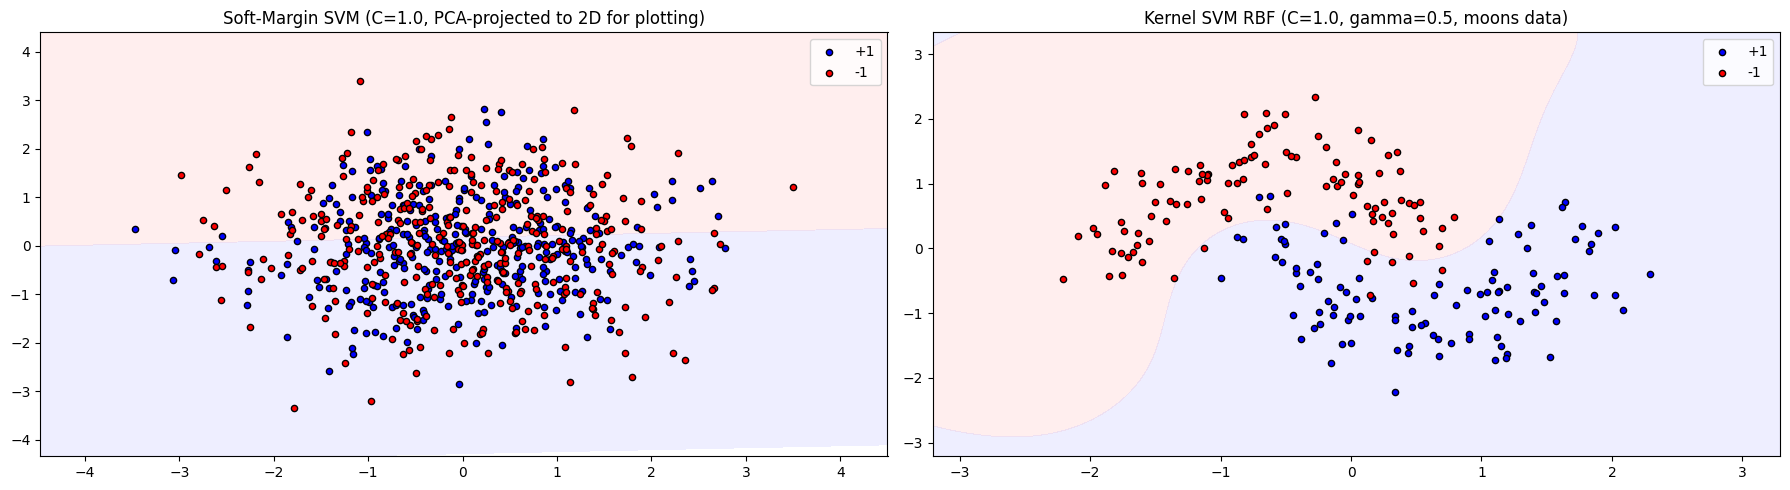

In [13]:
def plot_decision_boundary(ax, X, y, predict_fn, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    Z = predict_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, levels=[-2, 0, 2], colors=["#FFAAAA", "#AAAAFF"])
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", edgecolor="k", label="+1", s=20)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="red", edgecolor="k", label="-1", s=20)
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

if X_train.shape[1] == 2:
    plot_decision_boundary(
        axes[1], X_train, y_train,
        lambda g: soft_margin_sklearn.decision_function(g),
        f"Soft-Margin SVM (C={C_default}, blobs data)"
    )
else:
    pca = PCA(n_components=2, random_state=42)
    X_train_2d = pca.fit_transform(X_train)

    soft_margin_2d = SVC(kernel="linear", C=C_default).fit(X_train_2d, y_train)
    plot_decision_boundary(
        axes[0], X_train_2d, y_train,
        lambda g: soft_margin_2d.decision_function(g),
        f"Soft-Margin SVM (C={C_default}, PCA-projected to 2D for plotting)"
    )

# Kernel SVM section: Xm_train (moons data) is always 2D by construction, so this
# one is safe regardless of what svm.csv looks like.
plot_decision_boundary(
    axes[1], Xm_train, ym_train,
    lambda g: kernel_sklearn.decision_function(g),
    f"Kernel SVM RBF (C={C_default}, gamma={gamma_default}, moons data)"
)

plt.tight_layout()
plt.show()

<h2 style="font-size:35px;">RESULTS SUMMARY PLOTS:</h2>

                                               Model  Precision    Recall  \
0                         Soft-Margin (cvxpy, C=1.0)   0.489510  0.466667   
1                       Soft-Margin (sklearn, C=1.0)   0.489510  0.466667   
2           Kernel SVM RBF (cvxpy, C=1.0, gamma=0.5)   0.862745  0.977778   
3         Kernel SVM RBF (sklearn, C=1.0, gamma=0.5)   0.862745  0.977778   
4  Linear SVM on moons data (sklearn) -- for cont...   0.807692  0.933333   
5                     Logistic Regression (baseline)   0.468966  0.453333   

   F1-Score  Accuracy  
0  0.477816  0.490000  
1  0.477816  0.490000  
2  0.916667  0.911111  
3  0.916667  0.911111  
4  0.865979  0.855556  
5  0.461017  0.470000  


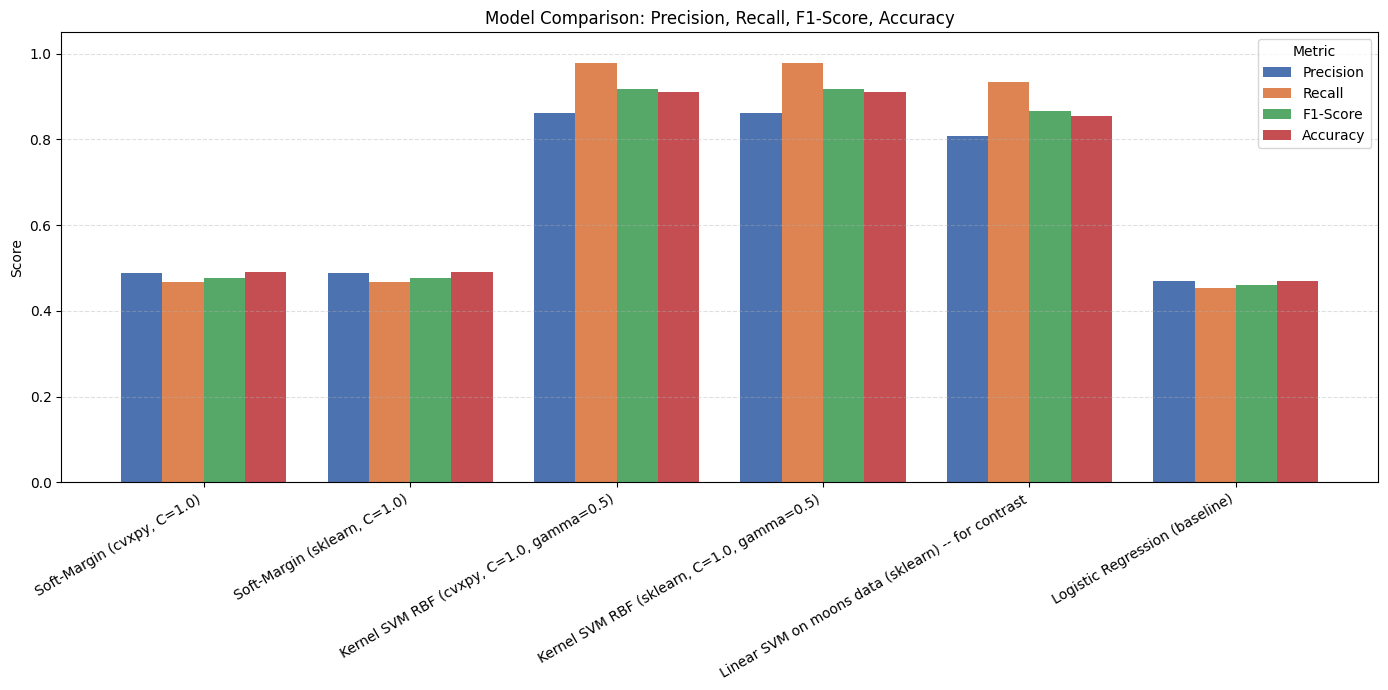

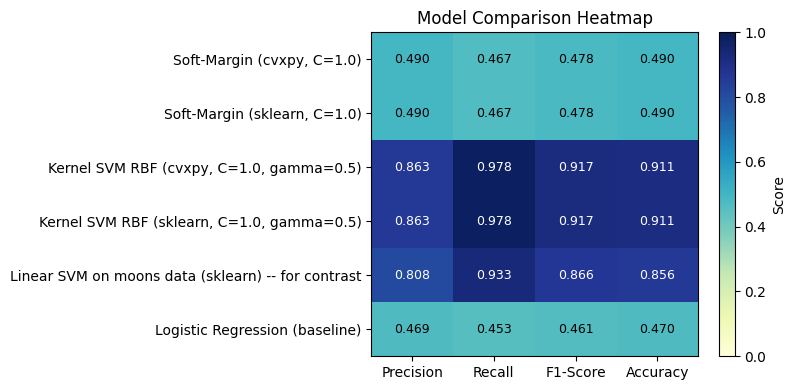

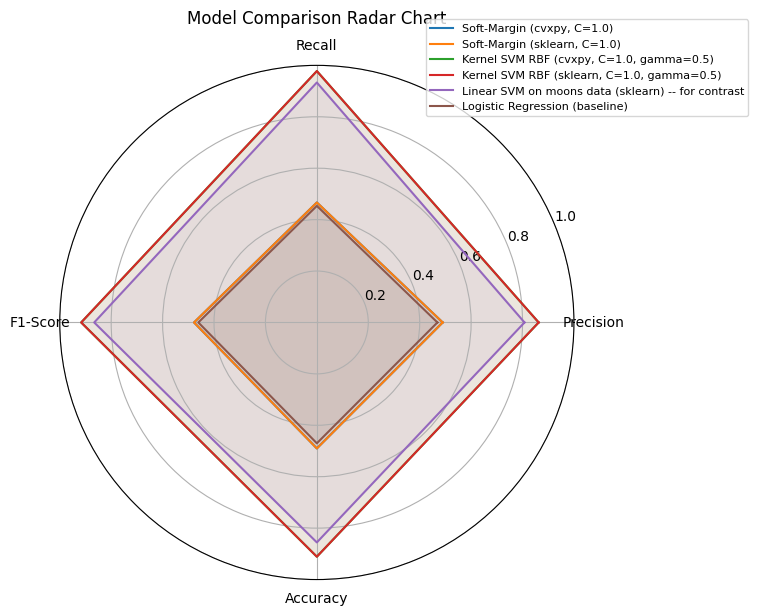

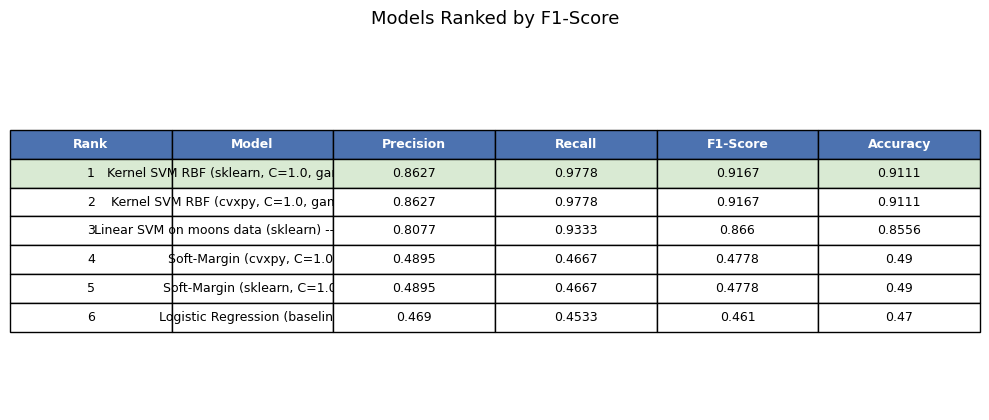

In [14]:
try:
    results_df
except NameError:
    csv_path = "model_comparison.csv"
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"'{csv_path}' not found and 'results_df' not in memory. "
            f"Run part2_svm.py first to generate results."
        )
    results_df = pd.read_csv(csv_path)

print(results_df)

metrics = ["Precision", "Recall", "F1-Score", "Accuracy"]

fig, ax = plt.subplots(figsize=(14, 7))

n_models = len(results_df)
n_metrics = len(metrics)
bar_width = 0.8 / n_metrics
x = np.arange(n_models)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, metric in enumerate(metrics):
    ax.bar(x + i * bar_width, results_df[metric], width=bar_width,
           label=metric, color=colors[i % len(colors)])

ax.set_xticks(x + bar_width * (n_metrics - 1) / 2)
ax.set_xticklabels(results_df["Model"], rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison: Precision, Recall, F1-Score, Accuracy")
ax.legend(title="Metric")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, max(4, 0.6 * n_models)))

heat_data = results_df.set_index("Model")[metrics]
im = ax.imshow(heat_data.values, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(metrics)
ax.set_yticks(np.arange(len(heat_data)))
ax.set_yticklabels(heat_data.index)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data.values[i, j]
        text_color = "white" if val > 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color, fontsize=9)

ax.set_title("Model Comparison Heatmap")
fig.colorbar(im, ax=ax, label="Score")

plt.tight_layout()
plt.show()

labels = metrics
n_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, row in results_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=1.5, label=row["Model"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison Radar Chart", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

ranked_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
ranked_df.insert(0, "Rank", ranked_df.index + 1)

fig, ax = plt.subplots(figsize=(10, 0.55 * len(ranked_df) + 1))
ax.axis("off")

table = ax.table(
    cellText=ranked_df.round(4).values,
    colLabels=ranked_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for j in range(len(ranked_df.columns)):
    table[0, j].set_facecolor("#4C72B0")
    table[0, j].set_text_props(color="white", weight="bold")

for j in range(len(ranked_df.columns)):
    table[1, j].set_facecolor("#D9EAD3")

ax.set_title("Models Ranked by F1-Score", fontsize=13, pad=20)

plt.tight_layout()
plt.show()

<h2 style="font-size:35px;">BONUS</h2>

In [15]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.1, 0.5, 1, 2, 5]

bonus_rows = []

# Soft-Margin: sweep C (manual cvxpy + sklearn) on blobs data
for C_val in C_values:
    w_c, b_c = SoftMarginSVM(X_train, y_train, C=C_val)
    y_pred_c = predict_linear(w_c, b_c, X_test)
    row = evaluate_predictions(y_test, y_pred_c, f"Soft-Margin cvxpy (C={C_val})")
    row["C"] = C_val
    row["Implementation"] = "cvxpy"
    row["Model Type"] = "Soft-Margin"
    bonus_rows.append(row)

    sk_model = SVC(kernel="linear", C=C_val)
    sk_model.fit(X_train, y_train)
    y_pred_sk = sk_model.predict(X_test)
    row_sk = evaluate_predictions(y_test, y_pred_sk, f"Soft-Margin sklearn (C={C_val})")
    row_sk["C"] = C_val
    row_sk["Implementation"] = "sklearn"
    row_sk["Model Type"] = "Soft-Margin"
    bonus_rows.append(row_sk)

# Kernel SVM: sweep C and gamma (sklearn, for tractable grid search
#     cvxpy dual solve is also demonstrated for one representative combination)
for C_val in C_values:
    for gamma_val in gamma_values:
        sk_kernel = SVC(kernel="rbf", C=C_val, gamma=gamma_val)
        sk_kernel.fit(Xm_train, ym_train)
        y_pred_sk_kernel = sk_kernel.predict(Xm_test)
        row_k = evaluate_predictions(
            ym_test, y_pred_sk_kernel, f"Kernel sklearn (C={C_val}, gamma={gamma_val})"
        )
        row_k["C"] = C_val
        row_k["gamma"] = gamma_val
        row_k["Implementation"] = "sklearn"
        row_k["Model Type"] = "Kernel"
        bonus_rows.append(row_k)

bonus_df = pd.DataFrame(bonus_rows)
bonus_df.to_csv("part2_bonus_regularization_sweep.csv", index=False)
print("Saved full sweep to 'part2_bonus_regularization_sweep.csv'")

# Report best C for soft-margin (by F1) and best (C, gamma) for kernel SVM
soft_margin_bonus = bonus_df[bonus_df["Model Type"] == "Soft-Margin"]
best_soft = soft_margin_bonus.loc[soft_margin_bonus["F1-Score"].idxmax()]
print("\nBest Soft-Margin configuration (by F1-Score):")
print(best_soft[["Model", "C", "Implementation", "Precision", "Recall", "F1-Score", "Accuracy"]])

kernel_bonus = bonus_df[bonus_df["Model Type"] == "Kernel"]
best_kernel = kernel_bonus.loc[kernel_bonus["F1-Score"].idxmax()]
print("\nBest Kernel SVM configuration (by F1-Score):")
print(best_kernel[["Model", "C", "gamma", "Implementation", "Precision", "Recall", "F1-Score", "Accuracy"]])

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31560\1911892468.py:9: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_31560\1911892468.py:9: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve()


Saved full sweep to 'part2_bonus_regularization_sweep.csv'

Best Soft-Margin configuration (by F1-Score):
Model             Soft-Margin cvxpy (C=0.01)
C                                       0.01
Implementation                         cvxpy
Precision                           0.465839
Recall                                   0.5
F1-Score                            0.482315
Accuracy                            0.463333
Name: 0, dtype: object

Best Kernel SVM configuration (by F1-Score):
Model             Kernel sklearn (C=1, gamma=2)
C                                           1.0
gamma                                       2.0
Implementation                          sklearn
Precision                              0.957447
Recall                                      1.0
F1-Score                               0.978261
Accuracy                               0.977778
Name: 23, dtype: object
